In [1]:
#--Intilize the chat model using the GROQ API key from the environment variables
import os 
from dotenv import load_dotenv
from langchain.chat_models import init_chat_model
load_dotenv()
os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")
# print("GROQ_API_KEY is set to:", os.getenv("GROQ_API_KEY"))
model = init_chat_model("groq:llama-3.1-8b-instant")
response = model.invoke("What is captial of WestBengal?")
print(response.content)

The capital of West Bengal, India is Kolkata.


In [5]:
# Step 1 ---Import the necessary modules and classes from langgraph and typing_extensions---
from langgraph.graph import StateGraph,START, END
from langgraph.graph.message import add_messages
from typing_extensions import Annotated
from typing import TypedDict
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition
from langchain_tavily import TavilySearch

# Step 2 ------------------ State definition for the graph------
class State(TypedDict):
    messages:Annotated[list, add_messages]

# Step 3 -----------------Define the Node function for the graph----------------
def tool_calling_node(state:State):
    return {"messages":[model.invoke(state["messages"])]}

# Step 4 --- Define the tools that will be used in the graph -----
Search_tool = TavilySearch(
    max_results=2,
    topice="general"
)
tools = [Search_tool]
# Step 5 ---------------- Define the graph and add the nodes to it----------------
graph_builder = StateGraph(State)
graph_builder.add_node("tool_calling_node",tool_calling_node)
graph_builder.add_node("tools",ToolNode(tools))
graph_builder.add_edge(START, "tool_calling_node")
graph_builder.add_conditional_edges("tool_calling_node", 
# If there is two nodes , we use add_conditional_edges to route the flow based on the condition
 #If the Lastest message(result) from assistant is a tool call -> tools_condation routes to tools                           
   tools_condition
)
graph_builder.add_edge("tools", "tool_calling_node") 
# After tool execution, we route back to the tool calling node to process 
# the results and generate a response for the user --Agentic AI / React Agent Architecture

# Step 6 ----------------- Execute the graph----------------
graph = graph_builder.compile()


#Step 7 ----------------- Test the graph with a query that requires tool usage----------------
User_query = "What is the captial of US and also search about it?"
response = graph.invoke({
    "messages":[{"role":"user","content":User_query}]
})

for m in response["messages"]:
    m.pretty_print()

================================ Human Message =================================

What is the captial of US and also search about it?
================================== Ai Message ==================================

The capital of the United States is Washington, D.C. (short for District of Columbia).

**About Washington, D.C.**

Washington, D.C. is a federal district located on the East Coast of the United States. It was created as the permanent capital of the United States in 1790, after the country's founding in 1776. The city is named after George Washington, the first president of the United States.

**History of Washington, D.C.**

Washington, D.C. was designed by Pierre Charles L'Enfant, a French-born architect, in 1791. The city was built on a site that was previously inhabited by Native American tribes, including the Nacotchtank and Piscataway. The area was chosen for its strategic location, being close to the Potomac and Anacostia rivers, and its proximity to the states of Vi

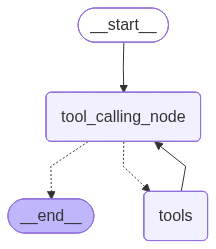

In [4]:
from IPython.display import Image , display
try:    
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception as e:
    print("Error visualizing the graph: ", e)